# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/peddikotlahimani/Flyrank-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question
*The research question and the decision it supports.*

Research question: Do things like how fresh a page is, how long it is, and what type of article it is have anything to do with getting a good click-through rate (CTR)?

Decision it supports: A content team trying to figure out what to fix first. If freshness or content type really do matter, they know to start there instead of just guessing.

## 2. Data
*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data: I used the starter dataset, content_refresh_anonymized.csv. It has 30,000 rows, one row per page, covering 32 pseudonymized clients. All the numbers in it (like impressions and CTR) are added up over a trailing 90-day window.

I did not use the full 79-million-row warehouse dataset for this work ,just this smaller starter file.

What I left out: I didn't use trend_direction or trend_pct as features, since those are meant for a different question (predicting decline) and using them could leak the answer. I also didn't use provider_used or model_used, since the data dictionary says those aren't allowed as features. Pages missing word_count weren't silently filled with 0 -- I gave them their own reason code instead, since guessing their word count would be misleading.

No client names, URLs, or private info appear anywhere -- all IDs are already pseudonyms (like content_id and client_id), so this is safe to share publicly.

## 3. Methodology
*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Methodology:

Label: I said a page has "good CTR" if its CTR is at or above the average CTR (0.51). This gave me a simple yes/no target called high_ctr.


Baseline: I first built a simple hand-written rule that scored pages using word count, impressions, and freshness. My first version of the baseline accidentally used ctr directly, which made it unfairly perfect, so I rebuilt a fair version using only the same 3 signals the model got, for an honest comparison.

Validation design: I split the data by client_id instead of randomly, so pages from the same client couldn't end up in both training and testing. I checked this worked by confirming zero clients appeared in both groups.

Leakage checks: I did not use trend_direction or trend_pct as features, since those are label-source columns for a different question (predicting decline) and could leak the answer. I also excluded provider_used and model_used, since the data dictionary marks those as not allowed. Missing word_count values were flagged instead of guessed, so they wouldn't quietly bias the results.

Assumptions: I assumed the trailing-90-day averages in this dataset are a fair snapshot of a page's real performance, and that content type, freshness, and length are reasonable, available signals a content team could realistically act on.

## 4. Results (vs baseline)
*Model vs baseline on the same split. The honest table.*

Results:

| Method | Precision@50 |
|---|---|
| Random guessing (base rate) | 0.13 |
| Fair baseline (hand-written rule) | 0.18 |
| Trained model (Logistic Regression) | 0.14 |

My simple hand-written rule slightly beat the trained model. Both only did a little better than random guessing. Looking closer, the model almost always predicted "low CTR" -- out of 6,163 test pages, it only guessed "high CTR" for 5 of them. This means the model wasn't really finding a strong pattern with the 3 signals I gave it (word count, impressions, and freshness). The simple rule held up just as well, if not slightly better, than the more complex model.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression

# 1. load data
df = pd.read_csv("https://raw.githubusercontent.com/peddikotlahimani/Flyrank-internship/main/data/raw/content_refresh_anonymized.csv")

# 2. labels
average_ctr = df["ctr"].mean()
df["high_ctr"] = (df["ctr"] >= average_ctr).astype(int)

# 3. fair baseline
median_wc = df["word_count"].median()
median_days = df["days_since_last_update"].median()

def fair_baseline(row):
    if pd.isna(row["word_count"]):
        return 0
    score = 0
    if row["word_count"] >= median_wc:
        score += 1
    if row["impressions_90d"] >= 100:
        score += 1
    if row["days_since_last_update"] <= median_days:
        score += 1
    return score

df["fair_baseline_score"] = df.apply(fair_baseline, axis=1)

# 4. grouped split by client_id
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["client_id"]))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

# 5. features + fill missing word_count
features = ["word_count", "impressions_90d", "days_since_last_update"]
train_df["word_count"] = train_df["word_count"].fillna(train_df["word_count"].median())
test_df["word_count"] = test_df["word_count"].fillna(train_df["word_count"].median())

X_train = train_df[features]
y_train = train_df["high_ctr"]
X_test = test_df[features]
y_test = test_df["high_ctr"]

# 6. train model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
test_df["model_score"] = model.predict_proba(X_test)[:, 1]

# 7. precision@K comparison
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

k = 50
base_rate = test_df["high_ctr"].mean()
fair_baseline_p_at_k = precision_at_k(test_df["fair_baseline_score"], test_df["high_ctr"], k)
model_p_at_k = precision_at_k(test_df["model_score"], test_df["high_ctr"], k)

print(f"Base rate: {base_rate:.2f}")
print(f"Fair baseline precision@{k}: {fair_baseline_p_at_k:.2f}")
print(f"Model precision@{k}: {model_p_at_k:.2f}")

Base rate: 0.13
Fair baseline precision@50: 0.18
Model precision@50: 0.14


In [ ]:
# This cell is for CODE (numbers, a query, a check).

print(f"Base rate: {base_rate:.2f}")
print(f"Fair baseline precision@50: {fair_baseline_p_at_k:.2f}")
print(f"Model precision@50: {model_p_at_k:.2f}")

Base rate: 0.13
Fair baseline precision@50: 0.18
Model precision@50: 0.14


## 5. Limitations
*What this work cannot claim.*

Limitations:

I only used a small piece of the data (30,000 rows), not the full dataset, so things might look different with more data.

I found that freshness and content type seem connected to CTR, but that doesn't mean changing them will definitely fix CTR. There could be other reasons behind what I saw that I can't see in this data.

My model barely did better than just guessing randomly, and it almost always guessed "low CTR." So the clues I gave it (word count, impressions, freshness) aren't strong enough on their own to really predict CTR well.

All my numbers come from just one 90-day period, so I don't know if the same patterns would show up at a different time of year.

Some pages were missing word count info, so I couldn't check content length for all of them.

Because of all this, I'm treating my findings as early signals, not proven facts.

## 6. Ranked recommendations
*The action playbook output — the paper's recommendations section.*

Ranked recommendations:

1. Fix ranking position first. Pages that show up higher in Google (like top 3) get way more clicks. This was the strongest thing I found, so it's the best place to start.

2. Update old pages. Pages updated more recently get more clicks than old, untouched ones. This showed up clearly, so it's a safe thing to try.

3. Look into why feedly-style articles do better. They had way more clicks than other article types. It's worth checking why, but I'm not 100% sure if it's the format itself or something else.

4. Don't assume longer is better. Shorter pages actually got more clicks in this data, so writing longer articles isn't automatically a good idea.

5. Don't judge a page by views alone. Getting a lot of views doesn't mean a lot of clicks -- these are two different things, so both need to be checked separately.

These are patterns I noticed in the data, not guaranteed facts. They're a good starting point to test, not a final answer.

## 7. Artifacts the paper embeds
*Generate/collect the charts and tables your deployed page will show.*

Artifacts for the paper:

1. CTR by position tier chart - shows my strongest finding: pages ranking higher on Google get a lot more clicks.
2. CTR by content type chart - shows that feedly-style articles had way more clicks than other types.
3. Results table - compares my baseline and model scores against random guessing.
4. Feature importance chart - shows which signals the model relied on most (freshness mattered most, impressions barely mattered at all).

I left out a histogram for impressions since I already described that pattern in numbers earlier (mean 5,200 vs median 731), so a chart wasn't necessary for it.

Folder ready!


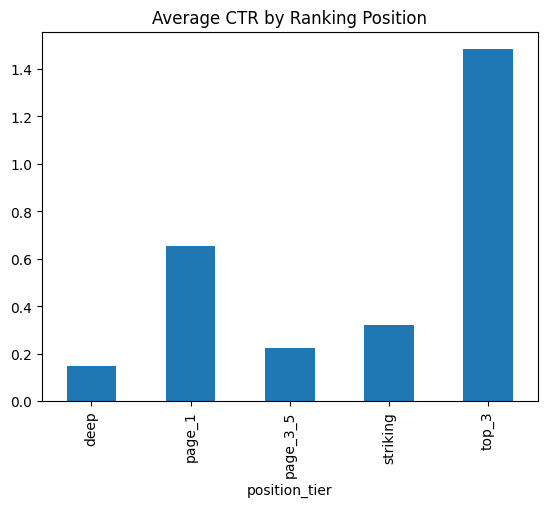

In [ ]:
# This cell is for CODE (numbers, a query, a check).

import os
os.makedirs("work/outputs", exist_ok=True)

print("Folder ready!")
import matplotlib.pyplot as plt

#group pages by position_tier, and find the average ctr for each group
grouped = df.groupby("position_tier")
average_ctr_per_group = grouped["ctr"].mean()

#make a bar chart from it
average_ctr_per_group.plot(kind="bar")

#add a title
plt.title("Average CTR by Ranking Position")

#save chart as a picture file
plt.savefig("work/outputs/ctr_by_position.png")

#show chart
plt.show()

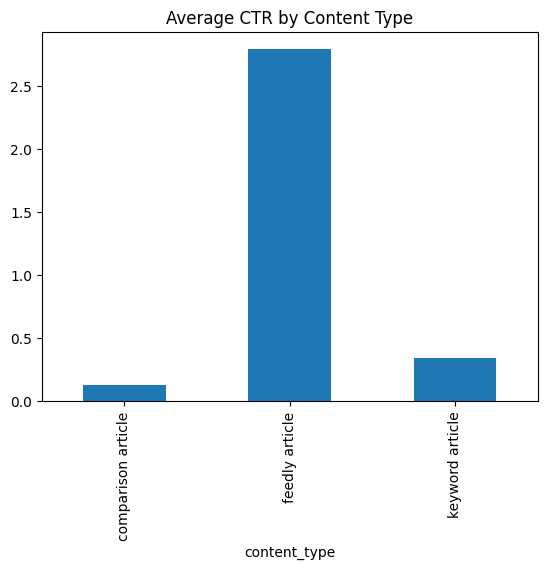

In [ ]:
# This cell is for CODE (numbers, a query, a check).
import matplotlib.pyplot as plt

#group pages by content_type, and find the average ctr for each group
grouped = df.groupby("content_type")
average_ctr_per_group = grouped["ctr"].mean()

#make a bar chart from it
average_ctr_per_group.plot(kind="bar")

#add a title
plt.title("Average CTR by Content Type")

#save it
plt.savefig("work/outputs/ctr_by_content_type.png")

#show it
plt.show()

Importance table ready!


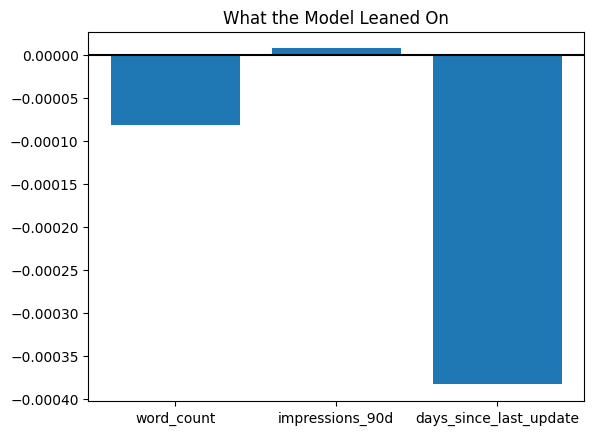

In [ ]:
# This cell is for CODE (numbers, a query, a check).

import pandas as pd

importance = pd.DataFrame({
    "feature": features,
    "weight": model.coef_[0]
})

print("Importance table ready!")
importance
import matplotlib.pyplot as plt

# make a simple bar chart: one bar per feature, height = its weight
plt.bar(importance["feature"], importance["weight"])

# add a title
plt.title("What the Model Leaned On")

# add a flat line at 0, just so it's easy to see positive vs negative
plt.axhline(0, color="black")

# save it
plt.savefig("work/outputs/feature_importance.png")

# show it
plt.show()

In [ ]:
# This cell is for CODE (numbers, a query, a check).

print("Random guessing:", base_rate)
print("Fair baseline:", fair_baseline_p_at_k)
print("Trained model:", model_p_at_k)

Random guessing: 0.12850884309589486
Fair baseline: 0.18
Trained model: 0.14


## Self-check

Before you submit, confirm each line honestly:

- [yes ] Every section above is filled — markdown thinking AND the code that backs it
- [yes ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [yes ] No client names, URLs, or private queries anywhere
- [yes ] My claims use careful words: observed, measured, directional, decision-support
- [yes ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [yes ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


5-minute demo outline:
1. My question: does content freshness, length, or type affect click-through rate (CTR)?
2. My data: 30,000 anonymized pages.
3. My simple rule (baseline) that scores pages.
4. What I found: freshness helped, content type mattered a lot, but longer content did NOT help.
5. My model: it barely beat random guessing, and I explain why.
6. My recommendations: fix ranking position first, update old content, don't assume longer is better.

Social-post cut:
I did a small project looking at what affects click-through rate on search pages. Turns out longer articles don't actually get more clicks -- shorter pages did better! Freshness and content type mattered way more. I also trained a model and it barely beat my simple hand-made rule, which taught me that simple isn't always worse.

Employer-facing summary:
I analyzed search performance data to find which content signals are linked to click-through rate. I built a simple rule-based baseline and a machine learning model, and compared them honestly. I found that freshness and content type mattered more than content length, and practiced careful, leak-free data analysis.